# F3 — Week 11 Performance Review

**Objective**: Review the optimisation performance of F3 across all 11 submission rounds and propose strategy for next submission.

**Function**: F3 (3D input, 1D output, maximisation)

**Week 10 Strategy**: SFGP Matérn-2.5 ARD + shift transform (y - y_min) + qLogNEI q=3 + 40 MLL restarts + noise_lb=1e-4 + 2048 raw samples.

This notebook loads the Week 11 data, visualises convergence and input-space coverage, evaluates performance, and proposes strategy improvements.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import math

# ── Function Configuration ──
FUNC_NUM = 3
N_DIMS = 3
N_INITIAL = 15
WEEK = 11
USE_LOG_SCALE = False
DATA_DIR = '../../data/f3/'

## Step 1 — Load Data

In [22]:
# Load Week 11 data
inputs = np.load(f'{DATA_DIR}updated_inputs - Week {WEEK}.npy')
outputs = np.load(f'{DATA_DIR}updated_outputs - Week {WEEK}.npy')

n_total = len(outputs)
n_submissions = n_total - N_INITIAL

print(f'F{FUNC_NUM} — Week {WEEK} Data Summary')
print(f'  Input dimensions:  {N_DIMS}')
print(f'  Total samples:     {n_total}')
print(f'  Initial samples:   {N_INITIAL}')
print(f'  Submissions:       {n_submissions}')
print(f'  Input shape:       {inputs.shape}')
print(f'  Output shape:      {outputs.shape}')
print(f'  Best output:       {outputs.max():.6g}')
print(f'  Worst output:      {outputs.min():.6g}')
print()

# Display data table
print('Sample | ' + ' | '.join([f'x{j+1:d}' for j in range(N_DIMS)]) + ' | y')
print('-' * (10 + N_DIMS * 12 + 15))
for i in range(n_total):
    label = 'init' if i < N_INITIAL else f'wk{i - N_INITIAL + 3}'
    row = f'{i+1:>4d}({label:>4s}) | '
    row += ' | '.join([f'{inputs[i, j]:.6f}' for j in range(N_DIMS)])
    row += f' | {outputs[i]:.6g}'
    print(row)

F3 — Week 11 Data Summary
  Input dimensions:  3
  Total samples:     26
  Initial samples:   15
  Submissions:       11
  Input shape:       (26, 3)
  Output shape:      (26,)
  Best output:       -0.0171258
  Worst output:      -0.398926

Sample | x1 | x2 | x3 | y
-------------------------------------------------------------
   1(init) | 0.171525 | 0.343917 | 0.248737 | -0.112122
   2(init) | 0.242114 | 0.644074 | 0.272433 | -0.0879629
   3(init) | 0.534906 | 0.398501 | 0.173389 | -0.111415
   4(init) | 0.492581 | 0.611593 | 0.340176 | -0.0348353
   5(init) | 0.134622 | 0.219917 | 0.458206 | -0.0480076
   6(init) | 0.345523 | 0.941360 | 0.269363 | -0.110621
   7(init) | 0.151837 | 0.439991 | 0.990882 | -0.398926
   8(init) | 0.645503 | 0.397143 | 0.919771 | -0.113869
   9(init) | 0.746912 | 0.284196 | 0.226300 | -0.131461
  10(init) | 0.170477 | 0.697032 | 0.149169 | -0.0941896
  11(init) | 0.220549 | 0.297825 | 0.343555 | -0.0469474
  12(init) | 0.666014 | 0.671985 | 0.246295 | -0.1

## Step 2 — Convergence Plot

Running best (maximum) objective value over all samples.

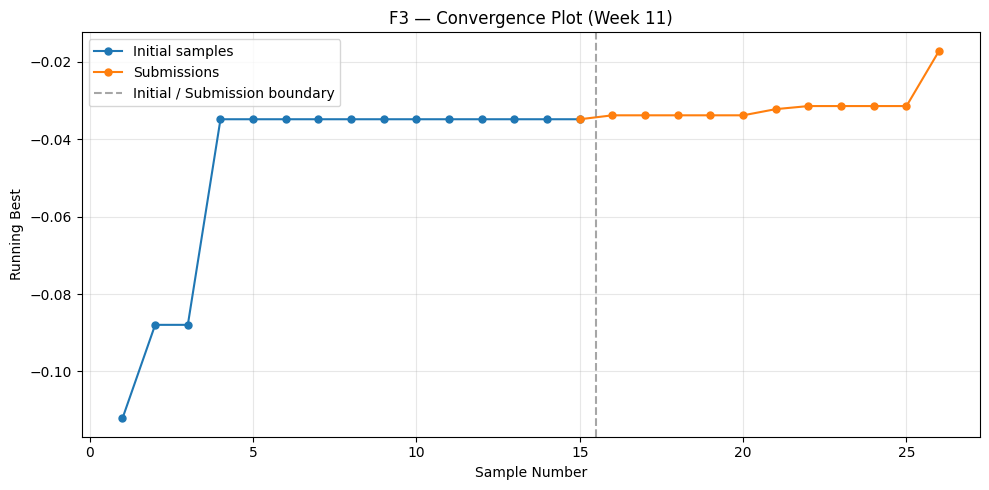

In [23]:
# Compute running best (maximisation)
running_best = np.maximum.accumulate(outputs)

fig, ax = plt.subplots(figsize=(10, 5))

x_all = np.arange(1, n_total + 1)
plot_vals = running_best
ax.set_ylabel('Running Best')

ax.plot(x_all[:N_INITIAL], plot_vals[:N_INITIAL], 'o-', color='tab:blue',
        label='Initial samples', markersize=5)
ax.plot(x_all[N_INITIAL-1:], plot_vals[N_INITIAL-1:], 'o-', color='tab:orange',
        label='Submissions', markersize=5)
ax.axvline(x=N_INITIAL + 0.5, color='grey', linestyle='--', alpha=0.7,
           label='Initial / Submission boundary')

ax.set_xlabel('Sample Number')
ax.set_title(f'F{FUNC_NUM} — Convergence Plot (Week {WEEK})')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Step 3 — 2D Pair Plots

Scatter plots of each unique pair of input dimensions showing spatial coverage. Initial samples in **blue** (unmarked), submission samples in **orange** (numbered by submission week).

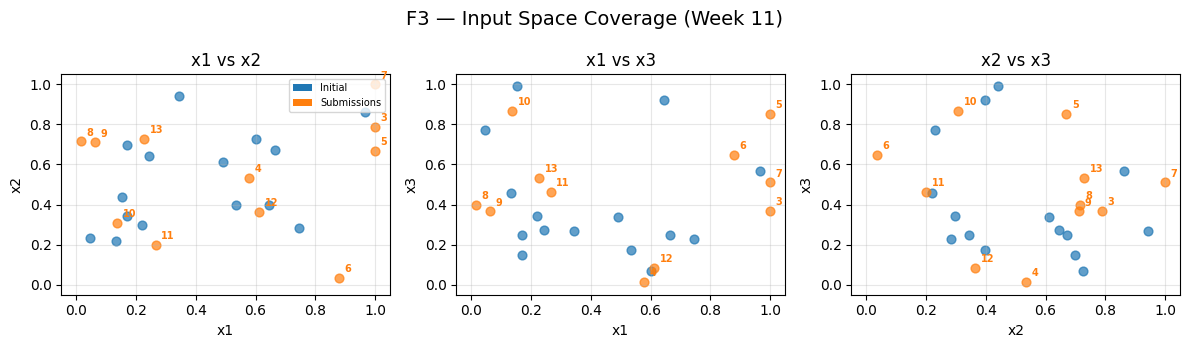

In [24]:
pairs = list(combinations(range(N_DIMS), 2))
n_pairs = len(pairs)

if n_pairs == 0:
    print('Only 1 dimension — no pair plots to display.')
else:
    n_cols = min(n_pairs, 3)
    n_rows = math.ceil(n_pairs / n_cols)
    fig_width = n_cols * 4
    fig_height = n_rows * 3.5

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height),
                             squeeze=False)

    for idx, (di, dj) in enumerate(pairs):
        row, col = divmod(idx, n_cols)
        ax = axes[row][col]

        ax.scatter(inputs[:N_INITIAL, di], inputs[:N_INITIAL, dj],
                   c='tab:blue', marker='o', s=40, alpha=0.7, label='Initial')

        for k in range(N_INITIAL, n_total):
            week_num = k - N_INITIAL + 3
            ax.scatter(inputs[k, di], inputs[k, dj],
                       c='tab:orange', marker='o', s=40, alpha=0.7)
            ax.annotate(str(week_num), (inputs[k, di], inputs[k, dj]),
                        textcoords='offset points', xytext=(4, 4),
                        fontsize=7, color='tab:orange', fontweight='bold')

        ax.set_xlabel(f'x{di+1}')
        ax.set_ylabel(f'x{dj+1}')
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(f'x{di+1} vs x{dj+1}')
        ax.grid(True, alpha=0.3)

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='tab:blue', label='Initial'),
                       Patch(facecolor='tab:orange', label='Submissions')]
    axes[0][0].legend(handles=legend_elements, loc='upper right', fontsize=7)

    for idx in range(n_pairs, n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        axes[row][col].set_visible(False)

    fig.suptitle(f'F{FUNC_NUM} — Input Space Coverage (Week {WEEK})', fontsize=14)
    fig.tight_layout()
    plt.show()

## Step 4 — Performance Evaluation

### Week 10 Strategy

- **Surrogate**: SFGP Matérn-2.5 ARD + shift transform (y - y_min)
- **Acquisition**: qLogNEI q=3 + 2048 raw samples
- **Key changes**: Increased q=1→3, raw samples 512→2048, noise_lb 1e-6→1e-4, MLL restarts 20→40

### Performance Summary

In [25]:
running_best = np.maximum.accumulate(outputs)
init_best = running_best[N_INITIAL - 1]

improvements = 0
consec_no_improve = 0
max_consec_no_improve = 0
prev_best = init_best

for j in range(N_INITIAL, n_total):
    if running_best[j] > prev_best:
        improvements += 1
        consec_no_improve = 0
    else:
        consec_no_improve += 1
        max_consec_no_improve = max(max_consec_no_improve, consec_no_improve)
    prev_best = running_best[j]

stalling = max_consec_no_improve >= 3

print(f'Best value (initial):     {init_best:.6g}')
print(f'Best value (final):       {running_best[-1]:.6g}')
print(f'Improvements:             {improvements}/{n_submissions}')
print(f'Max consecutive no-improve: {max_consec_no_improve}')
print(f'Stalling (≥3 consec):     {stalling}')
print()

print('Week | Output         | Best-so-far    | Improved?')
print('-' * 55)
for j in range(N_INITIAL, n_total):
    week_num = j - N_INITIAL + 3
    improved = '✓' if (j == N_INITIAL and outputs[j] > init_best) or \
               (j > N_INITIAL and running_best[j] > running_best[j-1]) else '✗'
    print(f'  {week_num:>2d} | {outputs[j]:>14.6g} | {running_best[j]:>14.6g} | {improved}')

Best value (initial):     -0.0348353
Best value (final):       -0.0171258
Improvements:             4/11
Max consecutive no-improve: 4
Stalling (≥3 consec):     True

Week | Output         | Best-so-far    | Improved?
-------------------------------------------------------
   3 |     -0.0338177 |     -0.0338177 | ✓
   4 |     -0.0725691 |     -0.0338177 | ✗
   5 |     -0.0394179 |     -0.0338177 | ✗
   6 |      -0.187072 |     -0.0338177 | ✗
   7 |      -0.049512 |     -0.0338177 | ✗
   8 |     -0.0322214 |     -0.0322214 | ✓
   9 |     -0.0314274 |     -0.0314274 | ✓
  10 |      -0.050946 |     -0.0314274 | ✗
  11 |     -0.0343614 |     -0.0314274 | ✗
  12 |     -0.0377062 |     -0.0314274 | ✗
  13 |     -0.0171258 |     -0.0171258 | ✓


## Step 5 — Strategy Proposals for Next Submission

Review the performance metrics and convergence plot above. Key considerations for F3:

1. **F3 had borderline stalling** through week 10 (3/10 improvements in negative output territory). The week 10 changes increased batch size and raw samples.

2. **If week 11 improved**: The q=3 + shift transform strategy is working in the negative-output landscape. Continue with:
   - Same surrogate and acquisition
   - Consider increasing q to 4 for even broader 3D coverage
   - Focus search near the best-so-far region with tighter acquisition bounds

3. **If week 11 did NOT improve**: The 3D space may need different treatment. Consider:
   - **Switch to Standardize(m=1)** instead of shift transform — the shift may be creating scale issues
   - **Increase raw_samples to 4096** for better 3D acquisition coverage
   - **Try Matérn-1.5 kernel** — the 3D landscape may have rougher features
   - **Increase noise_lb to 1e-3** — with negative outputs, the GP may be overfitting
   - **Add trust region** around current best to focus exploitation in the promising region

4. **General**: F3 operates in negative territory (best ≈ -0.03). Small improvements in absolute terms may represent significant progress. Verify the output transform is appropriate for the output range.

## ARD Feature Relevance Analysis

Automatic Relevance Determination (ARD) assigns a separate lengthscale parameter to each input dimension in the GP kernel. **Smaller lengthscale → the model is more sensitive to that dimension → higher relevance.**

Below we fit a SingleTaskGP with a Matérn-2.5 ARD kernel on the current data, extract the per-dimension lengthscales, and visualise the normalised relevance scores. The output transform matches the optimisation notebook: shift (y − y_min).

In [26]:
import torch
import gpytorch
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.kernels import MaternKernel, ScaleKernel
from gpytorch.priors import GammaPrior
from gpytorch.constraints import GreaterThan

# Prepare training data (match optimisation notebook transform: shift y - y_min)
X_train = torch.tensor(inputs, dtype=torch.float64)
Y_train = torch.tensor(outputs - outputs.min(), dtype=torch.float64).unsqueeze(-1)

# Fit SingleTaskGP with Matérn-2.5 ARD kernel
covar_module = ScaleKernel(
    MaternKernel(nu=2.5, ard_num_dims=N_DIMS, lengthscale_prior=GammaPrior(3.0, 6.0)),
    outputscale_prior=GammaPrior(2.0, 0.15),
)
model = SingleTaskGP(X_train, Y_train, covar_module=covar_module)
model.likelihood.noise_covar.register_constraint("raw_noise", GreaterThan(1e-4))
mll = ExactMarginalLogLikelihood(model.likelihood, model)
fit_gpytorch_mll(mll)

# Extract ARD lengthscales
lengthscales = model.covar_module.base_kernel.lengthscale.detach().squeeze().numpy()
dim_names = ["x1", "x2", "x3"]

print(f"F{FUNC_NUM}: ARD Lengthscales (Matérn-2.5 kernel)")
print(f"{'Dimension':<15} {'Lengthscale':>12}")
print("-" * 28)
for name, ls in zip(dim_names, lengthscales):
    print(f"{name:<15} {ls:>12.6f}")

F3: ARD Lengthscales (Matérn-2.5 kernel)
Dimension        Lengthscale
----------------------------
x1                  0.975068
x2                  0.906374
x3                  0.100182


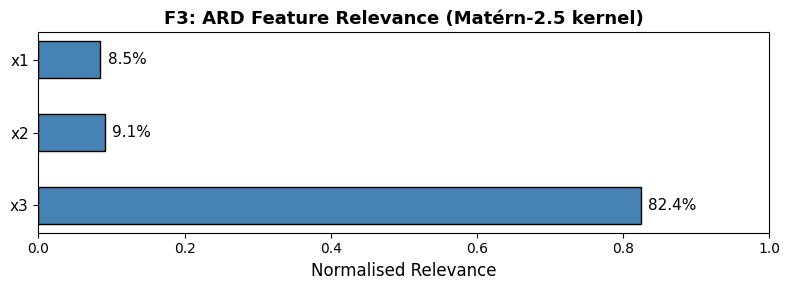

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Compute normalised relevance: relevance = 1/lengthscale, then normalise to sum to 1
inv_lengthscales = 1.0 / lengthscales
relevance = inv_lengthscales / inv_lengthscales.sum()

# Plot horizontal bar chart
fig, ax = plt.subplots(figsize=(8, max(3, len(dim_names) * 0.6)))
y_pos = np.arange(len(dim_names))
bars = ax.barh(y_pos, relevance, color="steelblue", edgecolor="black", height=0.5)

# Annotate bars with percentage
for bar, rel in zip(bars, relevance):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{rel:.1%}", va="center", fontsize=11)

ax.set_yticks(y_pos)
ax.set_yticklabels(dim_names, fontsize=11)
ax.set_xlabel("Normalised Relevance", fontsize=12)
ax.set_title(f"F{FUNC_NUM}: ARD Feature Relevance (Matérn-2.5 kernel)", fontsize=13, fontweight="bold")
ax.set_xlim(0, min(1.0, relevance.max() * 1.3))
ax.invert_yaxis()
plt.tight_layout()
plt.show()